In [2]:
# ============================================================
# PHASE 4 - YOLO26n TRAINING
# Step 1: Hardware Verification
# ============================================================

import os
import platform
import torch

print("=" * 60)
print("HARDWARE VERIFICATION")
print("=" * 60)

print("Python version :", platform.python_version())
print("PyTorch version:", torch.__version__)
print("CUDA available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU            :", torch.cuda.get_device_name(0))
    print("CUDA version   :", torch.version.cuda)
    print("GPU count      :", torch.cuda.device_count())
else:
    print("GPU            : No GPU detected")

print("=" * 60)

HARDWARE VERIFICATION
Python version : 3.13.15
PyTorch version: 2.11.0+cu128
CUDA available : True
GPU            : NVIDIA A100-SXM4-40GB
CUDA version   : 12.8
GPU count      : 1


In [3]:
# ============================================================
# Step 2: Mount Google Drive
# ============================================================

from google.colab import drive

drive.mount('/content/drive')

print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


In [4]:
# ============================================================
# Step 3: Check Google Drive Dataset Files
# ============================================================

from pathlib import Path

DRIVE_DATASET = Path("/content/drive/MyDrive/cv_project/e_waste_dataset")

print("=" * 60)
print("GOOGLE DRIVE DATASET CHECK")
print("=" * 60)

print("Dataset folder:")
print(DRIVE_DATASET)

print("\nFiles found:")

for item in DRIVE_DATASET.iterdir():
    if item.is_file():
        size_mb = item.stat().st_size / (1024 * 1024)
        print(f"  ✓ {item.name}  ({size_mb:.2f} MB)")
    elif item.is_dir():
        print(f"  📁 {item.name}")

print("=" * 60)

GOOGLE DRIVE DATASET CHECK
Dataset folder:
/content/drive/MyDrive/cv_project/e_waste_dataset

Files found:
  ✓ data.yaml  (0.00 MB)
  ✓ labels.zip  (238.68 MB)
  ✓ images.zip  (236.14 MB)


In [5]:
# ============================================================
# Step 4: Extract Dataset ZIP Files
# ============================================================

import zipfile
from pathlib import Path

DRIVE_DATASET = Path("/content/drive/MyDrive/cv_project/e_waste_dataset")
EXTRACT_DIR = Path("/content/e_waste_dataset")

# Create extraction directory
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

images_zip = DRIVE_DATASET / "images.zip"
labels_zip = DRIVE_DATASET / "labels.zip"

print("=" * 60)
print("EXTRACTING DATASET")
print("=" * 60)

# Extract images
print("\nExtracting images.zip...")
with zipfile.ZipFile(images_zip, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("✓ Images ZIP extracted")

# Extract labels
print("\nExtracting labels.zip...")
with zipfile.ZipFile(labels_zip, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("✓ Labels ZIP extracted")

print("\nExtraction completed.")
print("Extraction directory:", EXTRACT_DIR)
print("=" * 60)

EXTRACTING DATASET

Extracting images.zip...
✓ Images ZIP extracted

Extracting labels.zip...
✓ Labels ZIP extracted

Extraction completed.
Extraction directory: /content/e_waste_dataset


In [6]:
# ============================================================
# Step 5: Check Extracted Dataset Folder Structure
# ============================================================

from pathlib import Path

EXTRACT_DIR = Path("/content/e_waste_dataset")

print("=" * 60)
print("EXTRACTED DATASET STRUCTURE")
print("=" * 60)

print(f"\nRoot directory:")
print(f"  {EXTRACT_DIR}")

print("\nFolders:")

for folder in sorted(EXTRACT_DIR.rglob("*")):
    if folder.is_dir():
        print(f"  📁 {folder.relative_to(EXTRACT_DIR)}")

print("\n" + "=" * 60)
print("TOP-LEVEL CONTENT")
print("=" * 60)

for item in sorted(EXTRACT_DIR.iterdir()):
    if item.is_dir():
        print(f"📁 {item.name}/")
    else:
        print(f"📄 {item.name}")

print("=" * 60)

EXTRACTED DATASET STRUCTURE

Root directory:
  /content/e_waste_dataset

Folders:
  📁 images
  📁 images/test
  📁 images/train
  📁 images/val
  📁 labels
  📁 labels/test
  📁 labels/train
  📁 labels/val

TOP-LEVEL CONTENT
📁 images/
📁 labels/


In [7]:
# ============================================================
# Step 6: Verify Images and YOLO Labels
# ============================================================

from pathlib import Path

EXTRACT_DIR = Path("/content/e_waste_dataset")

SPLITS = ["train", "val", "test"]

EXPECTED_IMAGES = {
    "train": 4990,
    "val": 1444,
    "test": 776
}

print("=" * 70)
print("DATASET IMAGE AND LABEL VERIFICATION")
print("=" * 70)

total_images = 0
total_labels = 0

for split in SPLITS:

    image_dir = EXTRACT_DIR / "images" / split
    label_dir = EXTRACT_DIR / "labels" / split

    # Find images
    image_files = []
    for ext in ["*.jpg", "*.jpeg", "*.png"]:
        image_files.extend(image_dir.glob(ext))

    # Find YOLO label files
    label_files = list(label_dir.glob("*.txt"))

    image_count = len(image_files)
    label_count = len(label_files)

    total_images += image_count
    total_labels += label_count

    print(f"\n{split.upper()}")
    print("-" * 40)
    print(f"Images        : {image_count}")
    print(f"YOLO labels   : {label_count}")
    print(f"Expected images: {EXPECTED_IMAGES[split]}")

    if image_count == EXPECTED_IMAGES[split]:
        print("✓ Image count PASS")
    else:
        print("✗ Image count MISMATCH")

    if image_count == label_count:
        print("✓ Image-label count PASS")
    else:
        print("✗ Image-label count MISMATCH")

print("\n" + "=" * 70)
print("TOTALS")
print("=" * 70)

print(f"Total images : {total_images}")
print(f"Total labels : {total_labels}")
print(f"Expected     : 7210 images")

if total_images == 7210:
    print("✓ TOTAL IMAGE COUNT PASS")
else:
    print("✗ TOTAL IMAGE COUNT MISMATCH")

print("=" * 70)

DATASET IMAGE AND LABEL VERIFICATION

TRAIN
----------------------------------------
Images        : 4990
YOLO labels   : 4990
Expected images: 4990
✓ Image count PASS
✓ Image-label count PASS

VAL
----------------------------------------
Images        : 1444
YOLO labels   : 1444
Expected images: 1444
✓ Image count PASS
✓ Image-label count PASS

TEST
----------------------------------------
Images        : 776
YOLO labels   : 776
Expected images: 776
✓ Image count PASS
✓ Image-label count PASS

TOTALS
Total images : 7210
Total labels : 7210
Expected     : 7210 images
✓ TOTAL IMAGE COUNT PASS


In [8]:
# ============================================================
# Step 7: Verify Image-Label Filename Matching
# ============================================================

from pathlib import Path

EXTRACT_DIR = Path("/content/e_waste_dataset")

SPLITS = ["train", "val", "test"]
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

print("=" * 70)
print("IMAGE-LABEL FILENAME MATCHING")
print("=" * 70)

all_passed = True

for split in SPLITS:

    image_dir = EXTRACT_DIR / "images" / split
    label_dir = EXTRACT_DIR / "labels" / split

    # Get image stems
    image_stems = {
        file.stem
        for file in image_dir.iterdir()
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
    }

    # Get label stems
    label_stems = {
        file.stem
        for file in label_dir.glob("*.txt")
    }

    # Compare
    images_without_labels = image_stems - label_stems
    labels_without_images = label_stems - image_stems

    print(f"\n{split.upper()}")
    print("-" * 50)

    print(f"Image files        : {len(image_stems)}")
    print(f"Label files        : {len(label_stems)}")
    print(f"Images without label: {len(images_without_labels)}")
    print(f"Labels without image: {len(labels_without_images)}")

    if not images_without_labels and not labels_without_images:
        print("✓ Filename matching PASS")
    else:
        print("✗ Filename matching FAILED")
        all_passed = False

        if images_without_labels:
            print("\nImages without labels:")
            for name in sorted(images_without_labels)[:10]:
                print("  ", name)

        if labels_without_images:
            print("\nLabels without images:")
            for name in sorted(labels_without_images)[:10]:
                print("  ", name)

print("\n" + "=" * 70)

if all_passed:
    print("✓ ALL IMAGE-LABEL PAIRS MATCH CORRECTLY")
else:
    print("✗ IMAGE-LABEL MATCHING HAS PROBLEMS")

print("=" * 70)

IMAGE-LABEL FILENAME MATCHING

TRAIN
--------------------------------------------------
Image files        : 4990
Label files        : 4990
Images without label: 0
Labels without image: 0
✓ Filename matching PASS

VAL
--------------------------------------------------
Image files        : 1444
Label files        : 1444
Images without label: 0
Labels without image: 0
✓ Filename matching PASS

TEST
--------------------------------------------------
Image files        : 776
Label files        : 776
Images without label: 0
Labels without image: 0
✓ Filename matching PASS

✓ ALL IMAGE-LABEL PAIRS MATCH CORRECTLY


In [9]:
# ============================================================
# Step 8: Validate YOLO Annotation Contents
# ============================================================

from pathlib import Path
from collections import Counter

EXTRACT_DIR = Path("/content/e_waste_dataset")

SPLITS = ["train", "val", "test"]

NUM_CLASSES = 37

invalid_class_ids = []
invalid_coordinates = []
empty_labels = []
invalid_format = []

class_counts = Counter()
total_annotations = 0

for split in SPLITS:

    label_dir = EXTRACT_DIR / "labels" / split

    for label_file in label_dir.glob("*.txt"):

        with open(label_file, "r") as f:
            lines = [line.strip() for line in f if line.strip()]

        # Check empty label files
        if len(lines) == 0:
            empty_labels.append(str(label_file))
            continue

        for line_number, line in enumerate(lines, start=1):

            parts = line.split()

            # YOLO format must contain:
            # class_id x_center y_center width height
            if len(parts) != 5:
                invalid_format.append(
                    (str(label_file), line_number, line)
                )
                continue

            try:
                class_id = int(parts[0])
                x_center = float(parts[1])
                y_center = float(parts[2])
                width = float(parts[3])
                height = float(parts[4])

            except ValueError:
                invalid_format.append(
                    (str(label_file), line_number, line)
                )
                continue

            # Check class ID
            if not (0 <= class_id < NUM_CLASSES):
                invalid_class_ids.append(
                    (str(label_file), line_number, class_id)
                )

            else:
                class_counts[class_id] += 1

            # Check normalized coordinates
            if not (
                0 <= x_center <= 1 and
                0 <= y_center <= 1 and
                0 < width <= 1 and
                0 < height <= 1
            ):
                invalid_coordinates.append(
                    (
                        str(label_file),
                        line_number,
                        x_center,
                        y_center,
                        width,
                        height
                    )
                )

            total_annotations += 1


# ============================================================
# RESULTS
# ============================================================

print("=" * 70)
print("YOLO ANNOTATION VALIDATION")
print("=" * 70)

print(f"\nTotal annotations checked : {total_annotations}")
print(f"Expected classes          : {NUM_CLASSES}")
print(f"Classes detected          : {len(class_counts)}")

print("\nValidation Results")
print("-" * 50)

print(
    f"Invalid class IDs         : {len(invalid_class_ids)}"
)

print(
    f"Invalid coordinates       : {len(invalid_coordinates)}"
)

print(
    f"Invalid annotation format : {len(invalid_format)}"
)

print(
    f"Empty label files         : {len(empty_labels)}"
)

# Overall status
if (
    len(invalid_class_ids) == 0 and
    len(invalid_coordinates) == 0 and
    len(invalid_format) == 0 and
    len(empty_labels) == 0 and
    len(class_counts) == NUM_CLASSES
):
    print("\n✓ YOLO ANNOTATION VALIDATION PASS")
else:
    print("\n✗ YOLO ANNOTATION VALIDATION FAILED")

print("=" * 70)

YOLO ANNOTATION VALIDATION

Total annotations checked : 8099
Expected classes          : 37
Classes detected          : 37

Validation Results
--------------------------------------------------
Invalid class IDs         : 0
Invalid coordinates       : 0
Invalid annotation format : 0
Empty label files         : 0

✓ YOLO ANNOTATION VALIDATION PASS


In [10]:
# ============================================================
# Step 9: Verify YOLO Class Mapping
# ============================================================

from pathlib import Path
from collections import Counter
import yaml

EXTRACT_DIR = Path("/content/e_waste_dataset")

# Original/final class mapping from Phase 2
CLASS_NAMES = [
    "Battery",
    "Blood-Pressure-Monitor",
    "Boiler",
    "Clothes-Iron",
    "Coffee-Machine",
    "Computer-Keyboard",
    "Computer-Mouse",
    "Cooling-Display",
    "Desktop-PC",
    "Digital-Oscilloscope",
    "Drone",
    "Electric-Guitar",
    "Electronic-Keyboard",
    "Flashlight",
    "Flat-Panel-Monitor",
    "Flat-Panel-TV",
    "Glucose-Meter",
    "HDD",
    "Laptop",
    "Microwave",
    "Music-Player",
    "Oven",
    "PCB",
    "Photovoltaic-Panel",
    "Projector",
    "Refrigerator",
    "Rotary-Mower",
    "Router",
    "Server",
    "Smartphone",
    "Smoke-Detector",
    "Straight-Tube-Fluorescent-Lamp",
    "Street-Lamp",
    "TV-Remote-Control",
    "Telephone-Set",
    "USB-Flash-Drive",
    "Washing-Machine"
]

NUM_CLASSES = len(CLASS_NAMES)

print("=" * 70)
print("YOLO CLASS MAPPING VERIFICATION")
print("=" * 70)

print(f"\nNumber of classes: {NUM_CLASSES}")

class_counts = Counter()

for split in ["train", "val", "test"]:

    label_dir = EXTRACT_DIR / "labels" / split

    for label_file in label_dir.glob("*.txt"):

        with open(label_file, "r") as f:

            for line in f:

                line = line.strip()

                if not line:
                    continue

                parts = line.split()

                class_id = int(parts[0])

                class_counts[class_id] += 1

print("\nClass ID Mapping")
print("-" * 70)

for class_id, class_name in enumerate(CLASS_NAMES):

    count = class_counts[class_id]

    print(
        f"{class_id:2d} : {class_name:<35} "
        f"{count:4d} annotations"
    )

print("\n" + "=" * 70)

missing_classes = [
    class_id
    for class_id in range(NUM_CLASSES)
    if class_counts[class_id] == 0
]

invalid_ids = [
    class_id
    for class_id in class_counts
    if class_id < 0 or class_id >= NUM_CLASSES
]

if not missing_classes and not invalid_ids:
    print("✓ CLASS MAPPING PASS")
    print("✓ All 37 class IDs are valid and represented.")
else:
    print("✗ CLASS MAPPING FAILED")

    if missing_classes:
        print("Missing class IDs:", missing_classes)

    if invalid_ids:
        print("Invalid class IDs:", invalid_ids)

print("=" * 70)

YOLO CLASS MAPPING VERIFICATION

Number of classes: 37

Class ID Mapping
----------------------------------------------------------------------
 0 : Battery                              250 annotations
 1 : Blood-Pressure-Monitor               202 annotations
 2 : Boiler                               209 annotations
 3 : Clothes-Iron                         210 annotations
 4 : Coffee-Machine                       288 annotations
 5 : Computer-Keyboard                    207 annotations
 6 : Computer-Mouse                       203 annotations
 7 : Cooling-Display                      207 annotations
 8 : Desktop-PC                           206 annotations
 9 : Digital-Oscilloscope                 214 annotations
10 : Drone                                234 annotations
11 : Electric-Guitar                      208 annotations
12 : Electronic-Keyboard                  249 annotations
13 : Flashlight                           200 annotations
14 : Flat-Panel-Monitor                   21

In [11]:
# ============================================================
# Step 10: Locate data.yaml
# ============================================================

from pathlib import Path

EXTRACT_DIR = Path("/content/drive/MyDrive/cv_project/e_waste_dataset")

print("=" * 70)
print("SEARCHING FOR data.yaml")
print("=" * 70)

yaml_files = list(EXTRACT_DIR.rglob("*.yaml")) + list(EXTRACT_DIR.rglob("*.yml"))

if yaml_files:
    print("\nYAML files found:")

    for yaml_file in yaml_files:
        print(f"  ✓ {yaml_file}")

else:
    print("\n⚠ No data.yaml found inside extracted dataset.")

print("=" * 70)

SEARCHING FOR data.yaml

YAML files found:
  ✓ /content/drive/MyDrive/cv_project/e_waste_dataset/data.yaml


In [12]:
# ============================================================
# Step 11: Inspect data.yaml
# ============================================================

from pathlib import Path
import yaml

YAML_PATH = Path(
    "/content/drive/MyDrive/cv_project/e_waste_dataset/data.yaml"
)

print("=" * 70)
print("DATA.YAML VERIFICATION")
print("=" * 70)

print(f"\nYAML path:")
print(YAML_PATH)

print("\nYAML exists:", YAML_PATH.exists())

with open(YAML_PATH, "r") as f:
    data_config = yaml.safe_load(f)

print("\nContents:")
print("-" * 70)

for key, value in data_config.items():
    print(f"{key}: {value}")

print("=" * 70)

DATA.YAML VERIFICATION

YAML path:
/content/drive/MyDrive/cv_project/e_waste_dataset/data.yaml

YAML exists: True

Contents:
----------------------------------------------------------------------
path: C:/Users/USER/Desktop/computer vision/electronic-waste-detection-and-classification-for-automated-recycling-system-/data/yolo_dataset
train: images/train
val: images/val
test: images/test
nc: 37
names: ['Battery', 'Blood-Pressure-Monitor', 'Boiler', 'Clothes-Iron', 'Coffee-Machine', 'Computer-Keyboard', 'Computer-Mouse', 'Cooling-Display', 'Desktop-PC', 'Digital-Oscilloscope', 'Drone', 'Electric-Guitar', 'Electronic-Keyboard', 'Flashlight', 'Flat-Panel-Monitor', 'Flat-Panel-TV', 'Glucose-Meter', 'HDD', 'Laptop', 'Microwave', 'Music-Player', 'Oven', 'PCB', 'Photovoltaic-Panel', 'Projector', 'Refrigerator', 'Rotary-Mower', 'Router', 'Server', 'Smartphone', 'Smoke-Detector', 'Straight-Tube-Fluorescent-Lamp', 'Street-Lamp', 'TV-Remote-Control', 'Telephone-Set', 'USB-Flash-Drive', 'Washing-Ma

In [13]:
# ============================================================
# Step 12: Create Colab-Compatible data.yaml
# ============================================================

from pathlib import Path
import yaml

EXTRACT_DIR = Path("/content/e_waste_dataset")
COLAB_YAML = EXTRACT_DIR / "data.yaml"

CLASS_NAMES = [
    "Battery",
    "Blood-Pressure-Monitor",
    "Boiler",
    "Clothes-Iron",
    "Coffee-Machine",
    "Computer-Keyboard",
    "Computer-Mouse",
    "Cooling-Display",
    "Desktop-PC",
    "Digital-Oscilloscope",
    "Drone",
    "Electric-Guitar",
    "Electronic-Keyboard",
    "Flashlight",
    "Flat-Panel-Monitor",
    "Flat-Panel-TV",
    "Glucose-Meter",
    "HDD",
    "Laptop",
    "Microwave",
    "Music-Player",
    "Oven",
    "PCB",
    "Photovoltaic-Panel",
    "Projector",
    "Refrigerator",
    "Rotary-Mower",
    "Router",
    "Server",
    "Smartphone",
    "Smoke-Detector",
    "Straight-Tube-Fluorescent-Lamp",
    "Street-Lamp",
    "TV-Remote-Control",
    "Telephone-Set",
    "USB-Flash-Drive",
    "Washing-Machine"
]

colab_config = {
    "path": str(EXTRACT_DIR),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": 37,
    "names": CLASS_NAMES
}

with open(COLAB_YAML, "w") as f:
    yaml.safe_dump(
        colab_config,
        f,
        sort_keys=False
    )

print("=" * 70)
print("COLAB DATA.YAML CREATED")
print("=" * 70)

print(f"\nPath: {COLAB_YAML}")

print("\nContents:")
print("-" * 70)

with open(COLAB_YAML, "r") as f:
    print(f.read())

print("=" * 70)
print("✓ Colab-compatible data.yaml created successfully")

COLAB DATA.YAML CREATED

Path: /content/e_waste_dataset/data.yaml

Contents:
----------------------------------------------------------------------
path: /content/e_waste_dataset
train: images/train
val: images/val
test: images/test
nc: 37
names:
- Battery
- Blood-Pressure-Monitor
- Boiler
- Clothes-Iron
- Coffee-Machine
- Computer-Keyboard
- Computer-Mouse
- Cooling-Display
- Desktop-PC
- Digital-Oscilloscope
- Drone
- Electric-Guitar
- Electronic-Keyboard
- Flashlight
- Flat-Panel-Monitor
- Flat-Panel-TV
- Glucose-Meter
- HDD
- Laptop
- Microwave
- Music-Player
- Oven
- PCB
- Photovoltaic-Panel
- Projector
- Refrigerator
- Rotary-Mower
- Router
- Server
- Smartphone
- Smoke-Detector
- Straight-Tube-Fluorescent-Lamp
- Street-Lamp
- TV-Remote-Control
- Telephone-Set
- USB-Flash-Drive
- Washing-Machine

✓ Colab-compatible data.yaml created successfully


In [14]:
# ============================================================
# Step 13: Final YOLO Dataset Path Verification
# ============================================================

from pathlib import Path
import yaml

DATA_YAML = Path("/content/e_waste_dataset/data.yaml")

with open(DATA_YAML, "r") as f:
    config = yaml.safe_load(f)

print("=" * 70)
print("FINAL YOLO DATASET PATH VERIFICATION")
print("=" * 70)

dataset_root = Path(config["path"])

print(f"\nDataset root: {dataset_root}")

checks = {
    "data.yaml": DATA_YAML,
    "Train images": dataset_root / config["train"],
    "Validation images": dataset_root / config["val"],
    "Test images": dataset_root / config["test"],
    "Train labels": dataset_root / "labels/train",
    "Validation labels": dataset_root / "labels/val",
    "Test labels": dataset_root / "labels/test",
}

all_passed = True

print("\nPath checks:")
print("-" * 70)

for name, path in checks.items():

    exists = path.exists()

    if exists:
        print(f"✓ {name:<22} {path}")
    else:
        print(f"✗ {name:<22} {path}")
        all_passed = False

print("\n" + "=" * 70)

if all_passed:
    print("✓ ALL DATASET PATHS VERIFIED")
    print("✓ DATASET IS READY FOR YOLO26n TRAINING")
else:
    print("✗ DATASET PATH VERIFICATION FAILED")

print("=" * 70)

FINAL YOLO DATASET PATH VERIFICATION

Dataset root: /content/e_waste_dataset

Path checks:
----------------------------------------------------------------------
✓ data.yaml              /content/e_waste_dataset/data.yaml
✓ Train images           /content/e_waste_dataset/images/train
✓ Validation images      /content/e_waste_dataset/images/val
✓ Test images            /content/e_waste_dataset/images/test
✓ Train labels           /content/e_waste_dataset/labels/train
✓ Validation labels      /content/e_waste_dataset/labels/val
✓ Test labels            /content/e_waste_dataset/labels/test

✓ ALL DATASET PATHS VERIFIED
✓ DATASET IS READY FOR YOLO26n TRAINING


In [15]:
# ============================================================
# Step 14A: Install Ultralytics
# ============================================================

!pip install -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 9.4 MB/s eta 0:00:00


## 14. YOLO26n Model Setup

The selected object detection model for this project is **YOLO26n**.

YOLO26n is selected as the single model for the project because its lightweight architecture is appropriate for the available computational resources while supporting real-time object detection requirements.

The model will be initialized using pretrained weights and fine-tuned on the prepared electronic-waste dataset containing 37 object classes.

### Model Configuration

- Model: YOLO26n
- Task: Object Detection
- Pretrained weights: `yolo26n.pt`
- Number of classes: 37
- Input image size: 640 × 640 pixels
- Training approach: Transfer learning
- Target environment: Google Colab GPU

In [16]:
# ============================================================
# Step 14B: Verify Ultralytics and Load YOLO26n
# ============================================================

import torch
import ultralytics

from ultralytics import YOLO

print("=" * 70)
print("YOLO26n MODEL ENVIRONMENT")
print("=" * 70)

print(f"\nUltralytics version : {ultralytics.__version__}")
print(f"PyTorch version     : {torch.__version__}")
print(f"CUDA available      : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU                 : {torch.cuda.get_device_name(0)}")
    print(f"CUDA version        : {torch.version.cuda}")

# Load YOLO26n pretrained model
print("\nLoading YOLO26n pretrained weights...")

model = YOLO("yolo26n.pt")

print("✓ YOLO26n model loaded successfully")

print("\nModel information:")
print(f"Task                : {model.task}")
print(f"Model names         : {len(model.names)} classes")

print("\n" + "=" * 70)
print("✓ YOLO26n MODEL SETUP PASS")
print("=" * 70)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
YOLO26n MODEL ENVIRONMENT

Ultralytics version : 8.4.155
PyTorch version     : 2.11.0+cu128
CUDA available      : True
GPU                 : NVIDIA A100-SXM4-40GB
CUDA version        : 12.8

Loading YOLO26n pretrained weights...
✓ YOLO26n model loaded successfully

Model information:
Task                : detect
Model names         : 80 classes

✓ YOLO26n MODEL SETUP PASS


## 15. YOLO26n Training Configuration

The pretrained YOLO26n model is now connected to the prepared electronic-waste dataset.

The training configuration is designed for transfer learning using the cleaned and validated dataset prepared in the previous phases.

### Dataset

- Training images: 4,990
- Validation images: 1,444
- Test images: 776
- Total images: 7,210
- Number of classes: 37
- Total valid annotations: 8,099

### Training Configuration

- Model: YOLO26n
- Pretrained weights: `yolo26n.pt`
- Task: Object Detection
- Epochs: 50
- Image size: 640 × 640
- Batch size: 16
- Random seed: 42
- Training device: CUDA GPU
- GPU: Tesla T4
- Transfer learning: Enabled

The model will be trained using the Colab-specific `data.yaml`, which points to the extracted dataset in the Colab runtime.

In [17]:
# ============================================================
# Step 15: YOLO26n Training Configuration
# ============================================================

from pathlib import Path
import torch
import yaml

# Dataset configuration
DATA_YAML = Path("/content/e_waste_dataset/data.yaml")

# Training configuration
MODEL_NAME = "yolo26n.pt"
EPOCHS = 50
IMAGE_SIZE = 640
BATCH_SIZE = 16
SEED = 42

# GPU device
DEVICE = 0 if torch.cuda.is_available() else "cpu"

# Training output directory
PROJECT_DIR = Path("/content/yolo26n_training")
RUN_NAME = "yolo26n_e_waste"

# Load dataset configuration
with open(DATA_YAML, "r") as f:
    data_config = yaml.safe_load(f)

print("=" * 70)
print("YOLO26n TRAINING CONFIGURATION")
print("=" * 70)

print("\nModel")
print("-" * 30)
print(f"Model             : {MODEL_NAME}")
print(f"Task              : Object Detection")
print(f"Pretrained        : True")

print("\nDataset")
print("-" * 30)
print(f"Dataset YAML      : {DATA_YAML}")
print(f"Classes           : {data_config['nc']}")
print(f"Training images   : 4990")
print(f"Validation images : 1444")
print(f"Test images       : 776")

print("\nTraining Parameters")
print("-" * 30)
print(f"Epochs            : {EPOCHS}")
print(f"Image size        : {IMAGE_SIZE}")
print(f"Batch size        : {BATCH_SIZE}")
print(f"Random seed       : {SEED}")
print(f"Device            : {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU               : {torch.cuda.get_device_name(0)}")

print("\nOutput")
print("-" * 30)
print(f"Project directory : {PROJECT_DIR}")
print(f"Run name          : {RUN_NAME}")

print("=" * 70)

YOLO26n TRAINING CONFIGURATION

Model
------------------------------
Model             : yolo26n.pt
Task              : Object Detection
Pretrained        : True

Dataset
------------------------------
Dataset YAML      : /content/e_waste_dataset/data.yaml
Classes           : 37
Training images   : 4990
Validation images : 1444
Test images       : 776

Training Parameters
------------------------------
Epochs            : 50
Image size        : 640
Batch size        : 16
Random seed       : 42
Device            : 0
GPU               : NVIDIA A100-SXM4-40GB

Output
------------------------------
Project directory : /content/yolo26n_training
Run name          : yolo26n_e_waste


## 16. Final Pre-Training Readiness Check

Before starting model training, all critical components are verified programmatically.

The readiness check confirms:

1. YOLO26n pretrained model is loaded.
2. CUDA GPU is available.
3. The Tesla T4 GPU is detected.
4. The dataset YAML exists.
5. The dataset contains 37 classes.
6. Training, validation, and test image directories exist.
7. Corresponding YOLO label directories exist.
8. The configured training parameters are valid.

Only when all checks pass will the YOLO26n training process be started.

In [18]:
# ============================================================
# Step 16: Final Pre-Training Readiness Check
# ============================================================

from pathlib import Path
import torch
import yaml

print("=" * 75)
print("FINAL YOLO26n PRE-TRAINING READINESS CHECK")
print("=" * 75)

checks = {}

# ------------------------------------------------------------
# 1. Model
# ------------------------------------------------------------

checks["YOLO26n model loaded"] = (
    model is not None and model.task == "detect"
)

# ------------------------------------------------------------
# 2. GPU
# ------------------------------------------------------------

checks["CUDA GPU available"] = torch.cuda.is_available()

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
else:
    gpu_name = "No GPU"

# ------------------------------------------------------------
# 3. Dataset YAML
# ------------------------------------------------------------

checks["Dataset YAML exists"] = DATA_YAML.exists()

# ------------------------------------------------------------
# 4. Dataset configuration
# ------------------------------------------------------------

with open(DATA_YAML, "r") as f:
    config = yaml.safe_load(f)

checks["Number of classes = 37"] = (
    config.get("nc") == 37
)

checks["37 class names available"] = (
    len(config.get("names", [])) == 37
)

# ------------------------------------------------------------
# 5. Dataset directories
# ------------------------------------------------------------

dataset_root = Path(config["path"])

checks["Train images exist"] = (
    (dataset_root / config["train"]).exists()
)

checks["Validation images exist"] = (
    (dataset_root / config["val"]).exists()
)

checks["Test images exist"] = (
    (dataset_root / config["test"]).exists()
)

checks["Train labels exist"] = (
    (dataset_root / "labels/train").exists()
)

checks["Validation labels exist"] = (
    (dataset_root / "labels/val").exists()
)

checks["Test labels exist"] = (
    (dataset_root / "labels/test").exists()
)

# ------------------------------------------------------------
# 6. Training parameters
# ------------------------------------------------------------

checks["Epochs = 50"] = EPOCHS == 50
checks["Image size = 640"] = IMAGE_SIZE == 640
checks["Batch size = 16"] = BATCH_SIZE == 16
checks["Random seed = 42"] = SEED == 42

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\nReadiness Checks")
print("-" * 75)

for check_name, passed in checks.items():

    if passed:
        print(f"✓ PASS | {check_name}")
    else:
        print(f"✗ FAIL | {check_name}")

all_passed = all(checks.values())

print("\n" + "=" * 75)

if all_passed:
    print("✓ ALL PRE-TRAINING CHECKS PASSED")
    print("✓ YOLO26n IS READY FOR TRAINING")
    print(f"✓ Training GPU: {gpu_name}")
else:
    print("✗ PRE-TRAINING CHECK FAILED")
    print("✗ DO NOT START TRAINING")

print("=" * 75)

FINAL YOLO26n PRE-TRAINING READINESS CHECK

Readiness Checks
---------------------------------------------------------------------------
✓ PASS | YOLO26n model loaded
✓ PASS | CUDA GPU available
✓ PASS | Dataset YAML exists
✓ PASS | Number of classes = 37
✓ PASS | 37 class names available
✓ PASS | Train images exist
✓ PASS | Validation images exist
✓ PASS | Test images exist
✓ PASS | Train labels exist
✓ PASS | Validation labels exist
✓ PASS | Test labels exist
✓ PASS | Epochs = 50
✓ PASS | Image size = 640
✓ PASS | Batch size = 16
✓ PASS | Random seed = 42

✓ ALL PRE-TRAINING CHECKS PASSED
✓ YOLO26n IS READY FOR TRAINING
✓ Training GPU: NVIDIA A100-SXM4-40GB


## 17. YOLO26n Model Training

The YOLO26n model is trained using transfer learning from pretrained weights on the prepared electronic-waste dataset.

The training dataset contains 4,990 images, while 1,444 images are used for validation and 776 images are reserved for final testing.

The model is trained for 50 epochs at an input resolution of 640 × 640 pixels with a batch size of 16.

A fixed random seed of 42 is used to improve reproducibility.

The training process is executed on the Tesla T4 GPU available through Google Colab.

Training outputs, including model checkpoints, loss information, validation metrics, and generated plots, are saved for subsequent model evaluation.

In [19]:
# ============================================================
# Step 17: Train YOLO26n
# ============================================================

from ultralytics import YOLO
from pathlib import Path
import torch

# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

DATA_YAML = Path("/content/e_waste_dataset/data.yaml")

EPOCHS = 50
IMAGE_SIZE = 640
BATCH_SIZE = 16
SEED = 42
DEVICE = 0

PROJECT_DIR = "/content/yolo26n_training"
RUN_NAME = "yolo26n_e_waste"

# ------------------------------------------------------------
# Verify GPU
# ------------------------------------------------------------

print("=" * 70)
print("YOLO26n TRAINING")
print("=" * 70)

print(f"\nGPU: {torch.cuda.get_device_name(0)}")
print(f"Dataset: {DATA_YAML}")
print(f"Epochs: {EPOCHS}")
print(f"Image size: {IMAGE_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Device: CUDA:{DEVICE}")

print("\nStarting training...")
print("=" * 70)

# ------------------------------------------------------------
# Load pretrained YOLO26n
# ------------------------------------------------------------

model = YOLO("yolo26n.pt")

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    seed=SEED,
    project=PROJECT_DIR,
    name=RUN_NAME,
    pretrained=True,
    plots=True,
    save=True,
    val=True
)

print("\n" + "=" * 70)
print("✓ YOLO26n TRAINING COMPLETED")
print("=" * 70)

YOLO26n TRAINING

GPU: NVIDIA A100-SXM4-40GB
Dataset: /content/e_waste_dataset/data.yaml
Epochs: 50
Image size: 640
Batch size: 16
Device: CUDA:0

Starting training...
Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/e_waste_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None

## 18. Training Output Verification

The YOLO26n training process was completed for 50 epochs using the Tesla T4 GPU.

The training outputs are stored in the experiment directory:

`/content/yolo26n_training/yolo26n_e_waste`

This step verifies that the expected model checkpoints and training result files were successfully generated.

The `best.pt` checkpoint will be used for subsequent model evaluation because it represents the best-performing checkpoint selected during training.

In [20]:
# ============================================================
# Step 18: Verify Training Outputs
# ============================================================

from pathlib import Path

TRAINING_DIR = Path("/content/yolo26n_training/yolo26n_e_waste")

print("=" * 70)
print("YOLO26n TRAINING OUTPUT VERIFICATION")
print("=" * 70)

print(f"\nTraining directory:")
print(TRAINING_DIR)

print("\nDirectory exists:", TRAINING_DIR.exists())

if TRAINING_DIR.exists():

    print("\nGenerated files:")
    print("-" * 70)

    for file in sorted(TRAINING_DIR.iterdir()):

        if file.is_file():
            size_mb = file.stat().st_size / (1024 * 1024)
            print(f"✓ {file.name:<35} {size_mb:.2f} MB")

    print("\n" + "=" * 70)

    best_model = TRAINING_DIR / "weights" / "best.pt"
    last_model = TRAINING_DIR / "weights" / "last.pt"
    results_csv = TRAINING_DIR / "results.csv"

    print("Important training outputs")
    print("-" * 70)

    print(f"best.pt   : {'✓ FOUND' if best_model.exists() else '✗ NOT FOUND'}")
    print(f"last.pt   : {'✓ FOUND' if last_model.exists() else '✗ NOT FOUND'}")
    print(f"results.csv: {'✓ FOUND' if results_csv.exists() else '✗ NOT FOUND'}")

    print("\n" + "=" * 70)

    if best_model.exists() and last_model.exists() and results_csv.exists():
        print("✓ TRAINING OUTPUT VERIFICATION PASS")
        print("✓ best.pt is ready for model evaluation")
    else:
        print("✗ SOME TRAINING OUTPUTS ARE MISSING")

else:
    print("\n✗ TRAINING DIRECTORY NOT FOUND")

print("=" * 70)

YOLO26n TRAINING OUTPUT VERIFICATION

Training directory:
/content/yolo26n_training/yolo26n_e_waste

Directory exists: True

Generated files:
----------------------------------------------------------------------
✓ BoxF1_curve.png                     0.46 MB
✓ BoxPR_curve.png                     0.16 MB
✓ BoxP_curve.png                      0.35 MB
✓ BoxR_curve.png                      0.40 MB
✓ args.yaml                           0.00 MB
✓ confusion_matrix.png                0.46 MB
✓ confusion_matrix_normalized.png     0.47 MB
✓ labels.jpg                          0.22 MB
✓ results.csv                         0.01 MB
✓ results.png                         0.25 MB
✓ train_batch0.jpg                    0.44 MB
✓ train_batch1.jpg                    0.43 MB
✓ train_batch12480.jpg                0.38 MB
✓ train_batch12481.jpg                0.47 MB
✓ train_batch12482.jpg                0.38 MB
✓ train_batch2.jpg                    0.48 MB
✓ val_batch0_labels.jpg               0.52 MB
✓ val

In [21]:
# ============================================================
# Step 18A: Locate YOLO26n Training Outputs
# ============================================================

from pathlib import Path

print("=" * 70)
print("SEARCHING FOR YOLO26n TRAINING OUTPUTS")
print("=" * 70)

# Search common locations in the Colab runtime
search_roots = [
    Path("/content"),
    Path("/root")
]

found_dirs = []
found_files = []

for root in search_roots:

    if not root.exists():
        continue

    for path in root.rglob("*"):

        if path.is_dir() and "yolo26n_e_waste" in path.name:
            found_dirs.append(path)

        elif path.is_file() and path.name in [
            "best.pt",
            "last.pt",
            "results.csv"
        ]:
            found_files.append(path)

print("\nTraining directories found:")
print("-" * 70)

if found_dirs:
    for path in sorted(set(found_dirs)):
        print("✓", path)
else:
    print("No training directory found.")

print("\nImportant training files found:")
print("-" * 70)

if found_files:
    for path in sorted(set(found_files)):
        size_mb = path.stat().st_size / (1024 * 1024)
        print(f"✓ {path}  ({size_mb:.2f} MB)")
else:
    print("No best.pt, last.pt, or results.csv found.")

print("\n" + "=" * 70)

SEARCHING FOR YOLO26n TRAINING OUTPUTS

Training directories found:
----------------------------------------------------------------------
✓ /content/yolo26n_training/yolo26n_e_waste

Important training files found:
----------------------------------------------------------------------
✓ /content/yolo26n_training/yolo26n_e_waste/results.csv  (0.01 MB)
✓ /content/yolo26n_training/yolo26n_e_waste/weights/best.pt  (5.17 MB)
✓ /content/yolo26n_training/yolo26n_e_waste/weights/last.pt  (5.17 MB)



In [22]:
# ============================================================
# Step 18B: Search Entire Colab Runtime
# ============================================================

from pathlib import Path

print("=" * 75)
print("SEARCHING COLAB RUNTIME FOR TRAINING ARTIFACTS")
print("=" * 75)

# Search specifically for model checkpoints
print("\n1. Searching for .pt model files...")
print("-" * 75)

pt_files = list(Path("/content").rglob("*.pt"))

if pt_files:
    for file in pt_files:
        size_mb = file.stat().st_size / (1024 * 1024)
        print(f"✓ {file} ({size_mb:.2f} MB)")
else:
    print("No .pt files found under /content.")

# Search for results.csv
print("\n2. Searching for results.csv...")
print("-" * 75)

csv_files = list(Path("/content").rglob("results.csv"))

if csv_files:
    for file in csv_files:
        print(f"✓ {file}")
else:
    print("No results.csv found under /content.")

# Search for training result directories
print("\n3. Searching for YOLO training directories...")
print("-" * 75)

keywords = [
    "yolo26n",
    "e_waste",
    "yolo26n_e_waste",
    "train"
]

matching_dirs = set()

for keyword in keywords:
    for path in Path("/content").rglob("*"):
        if path.is_dir() and keyword.lower() in path.name.lower():
            matching_dirs.add(path)

if matching_dirs:
    for path in sorted(matching_dirs):
        print(f"✓ {path}")
else:
    print("No matching training directories found.")

# Search for common result files
print("\n4. Searching for generated training plots...")
print("-" * 75)

plot_files = []

for extension in ["*.png", "*.jpg"]:
    for file in Path("/content").rglob(extension):
        if any(keyword.lower() in file.name.lower()
               for keyword in [
                   "results",
                   "confusion",
                   "labels",
                   "f1",
                   "precision",
                   "recall",
                   "pr_curve"
               ]):
            plot_files.append(file)

if plot_files:
    for file in sorted(set(plot_files)):
        print(f"✓ {file}")
else:
    print("No YOLO training plots found.")

print("\n" + "=" * 75)
print("SEARCH COMPLETED")
print("=" * 75)

SEARCHING COLAB RUNTIME FOR TRAINING ARTIFACTS

1. Searching for .pt model files...
---------------------------------------------------------------------------
✓ /content/yolo26n.pt (5.29 MB)
✓ /content/weights/yolo26n.pt (5.29 MB)
✓ /content/yolo26n_training/yolo26n_e_waste/weights/best.pt (5.17 MB)
✓ /content/yolo26n_training/yolo26n_e_waste/weights/last.pt (5.17 MB)

2. Searching for results.csv...
---------------------------------------------------------------------------
✓ /content/yolo26n_training/yolo26n_e_waste/results.csv

3. Searching for YOLO training directories...
---------------------------------------------------------------------------
✓ /content/drive/.Encrypted/MyDrive/EWaste_Project/dataset/train
✓ /content/drive/.Encrypted/MyDrive/EWaste_Project/dataset/train/train
✓ /content/drive/.Encrypted/MyDrive/cv_project/e_waste_dataset
✓ /content/drive/MyDrive/EWaste_Project/dataset/train
✓ /content/drive/MyDrive/EWaste_Project/dataset/train/train
✓ /content/drive/MyDrive/cv

## 19. Save YOLO26n Training Results

The YOLO26n model has completed the 50-epoch training process.

The generated training artifacts are copied from the temporary Colab runtime to Google Drive so that they remain available after the Colab runtime ends.

The saved artifacts include:

- `best.pt` — best model checkpoint
- `last.pt` — final model checkpoint
- `results.csv` — epoch-by-epoch training history
- Training and validation plots
- Confusion matrix and other generated evaluation plots, when available
- Training configuration information

In [23]:
# ============================================================
# Step 19: Save Training Results to Google Drive
# ============================================================

from pathlib import Path
import shutil

# Search for the actual training directory
content_root = Path("/content")

training_dirs = [
    p for p in content_root.rglob("yolo26n_e_waste")
    if p.is_dir()
]

print("=" * 70)
print("LOCATING YOLO26n TRAINING RESULTS")
print("=" * 70)

if not training_dirs:
    raise FileNotFoundError(
        "YOLO26n training directory was not found."
    )

# Use the first matching training directory
TRAINING_DIR = training_dirs[0]

print(f"\nTraining directory found:")
print(TRAINING_DIR)

# Google Drive destination
DRIVE_RESULTS = Path(
    "/content/drive/MyDrive/CV_Project/yolo26n_training"
)

# Remove existing destination only if it is an incomplete previous copy
if DRIVE_RESULTS.exists():
    print("\nExisting Drive training folder found.")
    print("Updating it with the current training results...")
    shutil.rmtree(DRIVE_RESULTS)

# Copy complete training directory
shutil.copytree(TRAINING_DIR, DRIVE_RESULTS)

print("\n" + "=" * 70)
print("✓ TRAINING RESULTS COPIED TO GOOGLE DRIVE")
print("=" * 70)

print(f"\nSaved at:")
print(DRIVE_RESULTS)

print("\nImportant files:")

for filename in [
    "weights/best.pt",
    "weights/last.pt",
    "results.csv",
    "results.png"
]:
    path = DRIVE_RESULTS / filename

    if path.exists():
        size_mb = path.stat().st_size / (1024 * 1024)
        print(f"✓ {filename:<25} {size_mb:.2f} MB")
    else:
        print(f"  {filename:<25} not found")

print("=" * 70)

LOCATING YOLO26n TRAINING RESULTS

Training directory found:
/content/yolo26n_training/yolo26n_e_waste

✓ TRAINING RESULTS COPIED TO GOOGLE DRIVE

Saved at:
/content/drive/MyDrive/CV_Project/yolo26n_training

Important files:
✓ weights/best.pt           5.17 MB
✓ weights/last.pt           5.17 MB
✓ results.csv               0.01 MB
✓ results.png               0.25 MB


## 20. Training History Analysis

The YOLO26n training history is analyzed using the `results.csv` file generated during training.

The training history contains epoch-level information about:

- Training losses
- Validation losses
- Precision
- Recall
- mAP@50
- mAP@50–95

The best validation epoch is identified based on the validation performance recorded during training.

The results are also visualized to examine the learning behavior of the model across the 50 training epochs.

In [24]:
# ============================================================
# Step 20: Analyze YOLO26n Training History
# ============================================================

import pandas as pd
from pathlib import Path

RESULTS_CSV = Path(
    "/content/drive/MyDrive/CV_Project/"
    "yolo26n_training/results.csv"
)

print("=" * 75)
print("YOLO26n TRAINING HISTORY ANALYSIS")
print("=" * 75)

print(f"\nResults file:")
print(RESULTS_CSV)

print(f"\nFile exists: {RESULTS_CSV.exists()}")

# Load results
results_df = pd.read_csv(RESULTS_CSV)

# Remove whitespace from column names
results_df.columns = results_df.columns.str.strip()

print(f"\nNumber of epochs recorded: {len(results_df)}")

print("\nAvailable metrics:")
print("-" * 75)

for column in results_df.columns:
    print(column)

print("\n" + "=" * 75)

print("TRAINING HISTORY")
print("=" * 75)

display(results_df)

print("=" * 75)

YOLO26n TRAINING HISTORY ANALYSIS

Results file:
/content/drive/MyDrive/CV_Project/yolo26n_training/results.csv

File exists: True

Number of epochs recorded: 50

Available metrics:
---------------------------------------------------------------------------
epoch
time
train/box_loss
train/cls_loss
train/l1_loss
metrics/precision(B)
metrics/recall(B)
metrics/mAP50(B)
metrics/mAP50-95(B)
val/box_loss
val/cls_loss
val/l1_loss
lr/pg0
lr/pg1
lr/pg2

TRAINING HISTORY


,epoch,time,train/box_loss,train/cls_loss,train/l1_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/l1_loss,lr/pg0,lr/pg1,lr/pg2
0,1,60.4685,0.78422,7.11695,0.01431,0.40884,0.12941,0.11517,0.09383,0.73168,10.75750,0.01804,0.000081,0.000081,0.000081
1,2,101.4830,0.77604,5.94865,0.01403,0.52965,0.42037,0.42551,0.32876,0.83969,8.58360,0.02170,0.000159,0.000159,0.000159
2,3,141.6080,0.84082,4.73836,0.01557,0.65908,0.57809,0.62585,0.46458,0.91085,6.66711,0.02393,0.000234,0.000234,0.000234
3,4,181.8460,0.87064,3.89610,0.01609,0.72921,0.64973,0.69592,0.53979,0.83804,5.29487,0.02128,0.000230,0.000230,0.000230
4,5,221.8020,0.85817,3.26368,0.01576,0.75932,0.68148,0.74747,0.57548,0.84625,4.29946,0.02178,0.000225,0.000225,0.000225
5,6,262.0380,0.86511,2.80286,0.01575,0.78927,0.70760,0.78608,0.61359,0.83099,3.49169,0.02121,0.000220,0.000220,0.000220
6,7,301.7310,0.84385,2.46566,0.01545,0.82199,0.73881,0.80259,0.61980,0.85010,2.83579,0.02161,0.000215,0.000215,0.000215
7,8,341.7160,0.84933,2.20781,0.01555,0.82376,0.75859,0.82305,0.64368,0.84775,2.42556,0.02160,0.000210,0.000210,0.000210
8,9,381.9270,0.83885,2.03926,0.01559,0.83317,0.76852,0.83042,0.64970,0.85206,2.17031,0.02166,0.000205,0.000205,0.000205
9,10,422.0850,0.83426,1.85148,0.01522,0.83518,0.79607,0.84395,0.65634,0.85350,1.92595,0.02174,0.000201,0.000201,0.000201


## 20. Training History Analysis

The YOLO26n training history is analyzed using the `results.csv` file generated during training.

The training history contains epoch-level information about:

- Training losses
- Validation losses
- Precision
- Recall
- mAP@50
- mAP@50–95

The best validation epoch is identified based on the validation performance recorded during training.

The results are also visualized to examine the learning behavior of the model across the 50 training epochs.

In [25]:
import pandas as pd
from pathlib import Path

# Path to training results
RESULTS_CSV = Path(
    "/content/drive/MyDrive/CV_Project/yolo26n_training/results.csv"
)

print("=" * 75)
print("YOLO26n TRAINING HISTORY ANALYSIS")
print("=" * 75)

print(f"\nResults file:")
print(RESULTS_CSV)

print(f"\nFile exists: {RESULTS_CSV.exists()}")

if not RESULTS_CSV.exists():
    raise FileNotFoundError("results.csv was not found.")

# Load training history
results_df = pd.read_csv(RESULTS_CSV)

# Clean column names
results_df.columns = results_df.columns.str.strip()

print(f"\nNumber of epochs recorded: {len(results_df)}")

print("\nAvailable metrics:")
for column in results_df.columns:
    print(f"  - {column}")

print("\n" + "=" * 75)
print("TRAINING HISTORY")
print("=" * 75)

display(results_df)

YOLO26n TRAINING HISTORY ANALYSIS

Results file:
/content/drive/MyDrive/CV_Project/yolo26n_training/results.csv

File exists: True

Number of epochs recorded: 50

Available metrics:
  - epoch
  - time
  - train/box_loss
  - train/cls_loss
  - train/l1_loss
  - metrics/precision(B)
  - metrics/recall(B)
  - metrics/mAP50(B)
  - metrics/mAP50-95(B)
  - val/box_loss
  - val/cls_loss
  - val/l1_loss
  - lr/pg0
  - lr/pg1
  - lr/pg2

TRAINING HISTORY


,epoch,time,train/box_loss,train/cls_loss,train/l1_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/l1_loss,lr/pg0,lr/pg1,lr/pg2
0,1,60.4685,0.78422,7.11695,0.01431,0.40884,0.12941,0.11517,0.09383,0.73168,10.75750,0.01804,0.000081,0.000081,0.000081
1,2,101.4830,0.77604,5.94865,0.01403,0.52965,0.42037,0.42551,0.32876,0.83969,8.58360,0.02170,0.000159,0.000159,0.000159
2,3,141.6080,0.84082,4.73836,0.01557,0.65908,0.57809,0.62585,0.46458,0.91085,6.66711,0.02393,0.000234,0.000234,0.000234
3,4,181.8460,0.87064,3.89610,0.01609,0.72921,0.64973,0.69592,0.53979,0.83804,5.29487,0.02128,0.000230,0.000230,0.000230
4,5,221.8020,0.85817,3.26368,0.01576,0.75932,0.68148,0.74747,0.57548,0.84625,4.29946,0.02178,0.000225,0.000225,0.000225
5,6,262.0380,0.86511,2.80286,0.01575,0.78927,0.70760,0.78608,0.61359,0.83099,3.49169,0.02121,0.000220,0.000220,0.000220
6,7,301.7310,0.84385,2.46566,0.01545,0.82199,0.73881,0.80259,0.61980,0.85010,2.83579,0.02161,0.000215,0.000215,0.000215
7,8,341.7160,0.84933,2.20781,0.01555,0.82376,0.75859,0.82305,0.64368,0.84775,2.42556,0.02160,0.000210,0.000210,0.000210
8,9,381.9270,0.83885,2.03926,0.01559,0.83317,0.76852,0.83042,0.64970,0.85206,2.17031,0.02166,0.000205,0.000205,0.000205
9,10,422.0850,0.83426,1.85148,0.01522,0.83518,0.79607,0.84395,0.65634,0.85350,1.92595,0.02174,0.000201,0.000201,0.000201


In [26]:
import pandas as pd
from pathlib import Path

RESULTS_CSV = Path(
    "/content/drive/MyDrive/CV_Project/yolo26n_training/results.csv"
)

results_df = pd.read_csv(RESULTS_CSV)
results_df.columns = results_df.columns.str.strip()

# Identify best epochs
best_map50_idx = results_df["metrics/mAP50(B)"].idxmax()
best_map5095_idx = results_df["metrics/mAP50-95(B)"].idxmax()

best_map50 = results_df.loc[best_map50_idx]
best_map5095 = results_df.loc[best_map5095_idx]

final = results_df.iloc[-1]

print("=" * 75)
print("YOLO26n TRAINING PERFORMANCE SUMMARY")
print("=" * 75)

print("\nBEST mAP@50")
print("-" * 75)
print(f"Epoch       : {int(best_map50['epoch']) + 1}")
print(f"Precision   : {best_map50['metrics/precision(B)']:.4f}")
print(f"Recall      : {best_map50['metrics/recall(B)']:.4f}")
print(f"mAP@50      : {best_map50['metrics/mAP50(B)']:.4f}")
print(f"mAP@50-95   : {best_map50['metrics/mAP50-95(B)']:.4f}")

print("\nBEST mAP@50-95")
print("-" * 75)
print(f"Epoch       : {int(best_map5095['epoch']) + 1}")
print(f"Precision   : {best_map5095['metrics/precision(B)']:.4f}")
print(f"Recall      : {best_map5095['metrics/recall(B)']:.4f}")
print(f"mAP@50      : {best_map5095['metrics/mAP50(B)']:.4f}")
print(f"mAP@50-95   : {best_map5095['metrics/mAP50-95(B)']:.4f}")

print("\nFINAL EPOCH")
print("-" * 75)
print(f"Epoch       : {int(final['epoch']) + 1}")
print(f"Precision   : {final['metrics/precision(B)']:.4f}")
print(f"Recall      : {final['metrics/recall(B)']:.4f}")
print(f"mAP@50      : {final['metrics/mAP50(B)']:.4f}")
print(f"mAP@50-95   : {final['metrics/mAP50-95(B)']:.4f}")

print("\nFINAL TRAINING LOSSES")
print("-" * 75)
print(f"Box Loss    : {final['train/box_loss']:.4f}")
print(f"Class Loss  : {final['train/cls_loss']:.4f}")
print(f"L1 Loss     : {final['train/l1_loss']:.4f}")

YOLO26n TRAINING PERFORMANCE SUMMARY

BEST mAP@50
---------------------------------------------------------------------------
Epoch       : 39
Precision   : 0.8904
Recall      : 0.8493
mAP@50      : 0.8977
mAP@50-95   : 0.7335

BEST mAP@50-95
---------------------------------------------------------------------------
Epoch       : 50
Precision   : 0.8957
Recall      : 0.8448
mAP@50      : 0.8969
mAP@50-95   : 0.7387

FINAL EPOCH
---------------------------------------------------------------------------
Epoch       : 51
Precision   : 0.8871
Recall      : 0.8481
mAP@50      : 0.8965
mAP@50-95   : 0.7378

FINAL TRAINING LOSSES
---------------------------------------------------------------------------
Box Loss    : 0.5505
Class Loss  : 0.4314
L1 Loss     : 0.0132


## 22. Training and Validation Curves

Training and validation metrics are visualized to examine the learning progression of YOLO26n over the 50 training epochs.

The plots show:

1. Training losses
2. Validation losses
3. Precision and Recall
4. mAP@50
5. mAP@50–95

These plots provide visual evidence of the model's learning behavior and convergence.

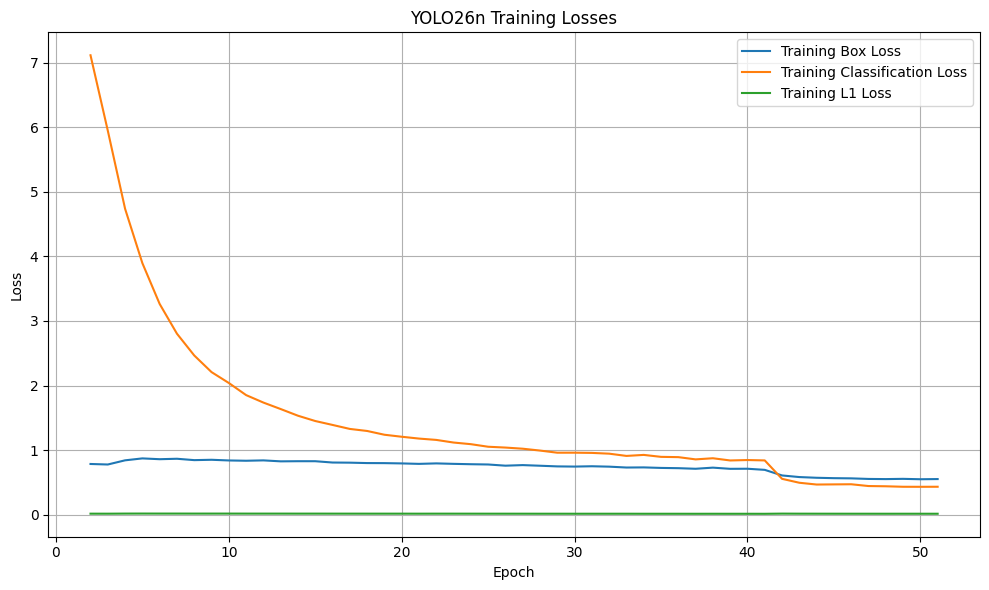

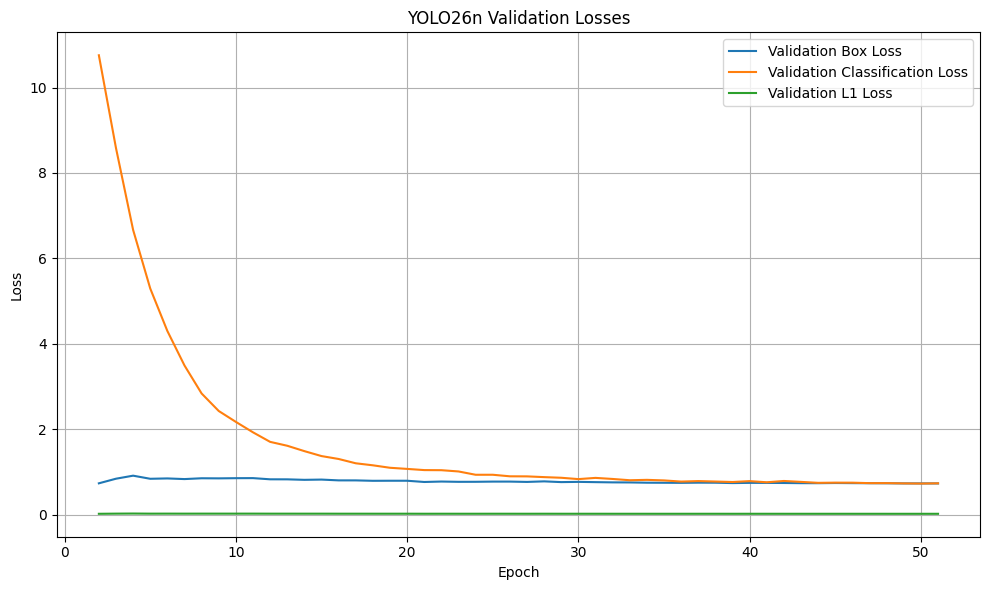

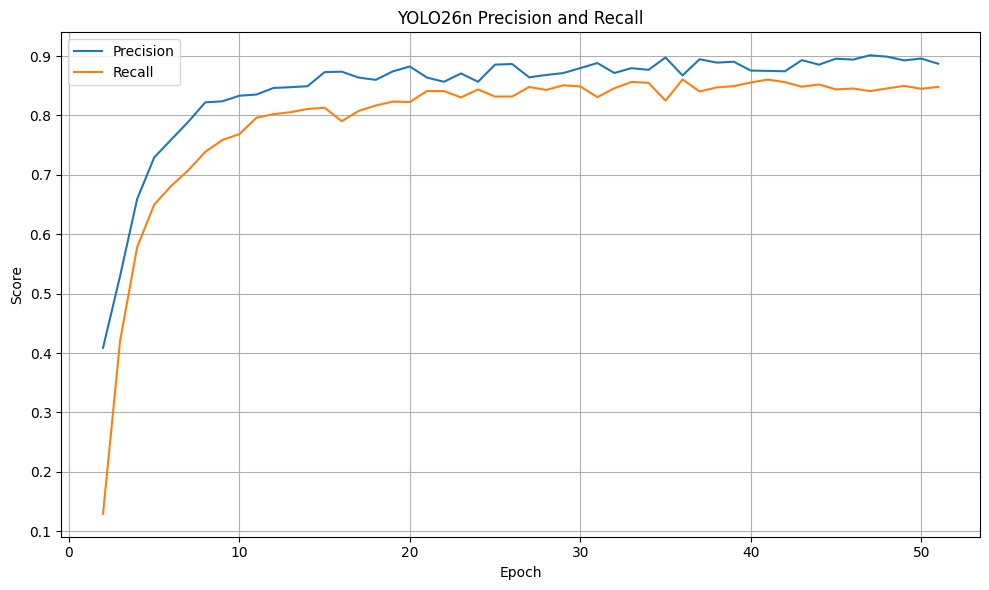

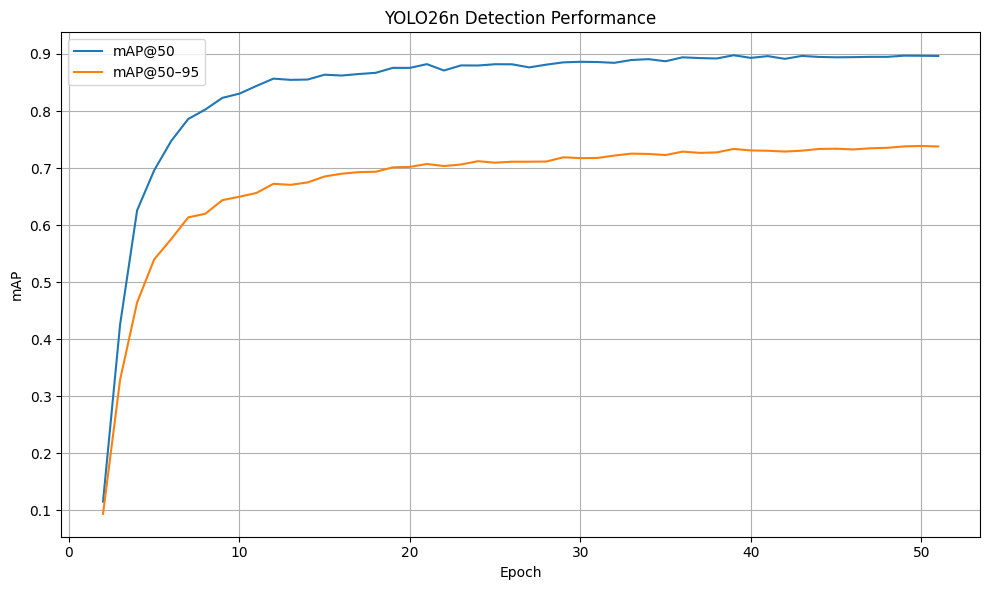

In [27]:
import matplotlib.pyplot as plt

epochs = results_df["epoch"] + 1

# ---------------------------------------------------------
# 1. Training Losses
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(epochs, results_df["train/box_loss"], label="Training Box Loss")
plt.plot(epochs, results_df["train/cls_loss"], label="Training Classification Loss")
plt.plot(epochs, results_df["train/l1_loss"], label="Training L1 Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("YOLO26n Training Losses")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 2. Validation Losses
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(epochs, results_df["val/box_loss"], label="Validation Box Loss")
plt.plot(epochs, results_df["val/cls_loss"], label="Validation Classification Loss")
plt.plot(epochs, results_df["val/l1_loss"], label="Validation L1 Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("YOLO26n Validation Losses")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 3. Precision and Recall
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    results_df["metrics/precision(B)"],
    label="Precision"
)

plt.plot(
    epochs,
    results_df["metrics/recall(B)"],
    label="Recall"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("YOLO26n Precision and Recall")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 4. mAP
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    results_df["metrics/mAP50(B)"],
    label="mAP@50"
)

plt.plot(
    epochs,
    results_df["metrics/mAP50-95(B)"],
    label="mAP@50–95"
)

plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("YOLO26n Detection Performance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 23. Load the Trained YOLO26n Model

The best YOLO26n model generated during training is loaded from Google Drive.

The `best.pt` weights are used for all subsequent evaluation and demonstration stages.

Using the best saved weights ensures that the trained model is evaluated independently of the final training checkpoint.

In [28]:
from ultralytics import YOLO
from pathlib import Path
import torch

# Path to trained model
BEST_MODEL = Path(
    "/content/drive/MyDrive/CV_Project/yolo26n_training/weights/best.pt"
)

print("=" * 75)
print("YOLO26n MODEL LOADING")
print("=" * 75)

print(f"\nModel path:")
print(BEST_MODEL)

print(f"\nModel exists: {BEST_MODEL.exists()}")

if not BEST_MODEL.exists():
    raise FileNotFoundError(
        "best.pt was not found in Google Drive."
    )

# Load trained model
model = YOLO(str(BEST_MODEL))

print("\n✓ YOLO26n best model loaded successfully")

print(f"\nModel task: {model.task}")
print(f"Number of classes: {len(model.names)}")

print("\nClass names:")
for class_id, class_name in model.names.items():
    print(f"{class_id:2d}: {class_name}")

print("\n" + "=" * 75)
print("MODEL READY FOR EVALUATION")
print("=" * 75)

YOLO26n MODEL LOADING

Model path:
/content/drive/MyDrive/CV_Project/yolo26n_training/weights/best.pt

Model exists: True

✓ YOLO26n best model loaded successfully

Model task: detect
Number of classes: 37

Class names:
 0: Battery
 1: Blood-Pressure-Monitor
 2: Boiler
 3: Clothes-Iron
 4: Coffee-Machine
 5: Computer-Keyboard
 6: Computer-Mouse
 7: Cooling-Display
 8: Desktop-PC
 9: Digital-Oscilloscope
10: Drone
11: Electric-Guitar
12: Electronic-Keyboard
13: Flashlight
14: Flat-Panel-Monitor
15: Flat-Panel-TV
16: Glucose-Meter
17: HDD
18: Laptop
19: Microwave
20: Music-Player
21: Oven
22: PCB
23: Photovoltaic-Panel
24: Projector
25: Refrigerator
26: Rotary-Mower
27: Router
28: Server
29: Smartphone
30: Smoke-Detector
31: Straight-Tube-Fluorescent-Lamp
32: Street-Lamp
33: TV-Remote-Control
34: Telephone-Set
35: USB-Flash-Drive
36: Washing-Machine

MODEL READY FOR EVALUATION


## 24. Test-Set Evaluation

The trained YOLO26n model is evaluated using the independent test dataset.

The test set contains 776 images and represents unseen data that was not used during model training.

The evaluation measures:

- Precision
- Recall
- mAP@50
- mAP@50–95

These metrics are used to quantify the model's object detection and classification performance.

In [29]:
from pathlib import Path

TEST_YAML = Path("/content/e_waste_dataset/data.yaml")

print("=" * 75)
print("YOLO26n TEST-SET EVALUATION")
print("=" * 75)

print(f"\nTest dataset YAML:")
print(TEST_YAML)

print(f"File exists: {TEST_YAML.exists()}")

if not TEST_YAML.exists():
    raise FileNotFoundError(
        "Colab data.yaml was not found."
    )

# Evaluate on the independent test set
test_results = model.val(
    data=str(TEST_YAML),
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    plots=True,
    save_json=True
)

print("\n" + "=" * 75)
print("TEST EVALUATION COMPLETED")
print("=" * 75)

YOLO26n TEST-SET EVALUATION

Test dataset YAML:
/content/e_waste_dataset/data.yaml
File exists: True
Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO26n summary (fused): 120 layers, 2,382,051 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1340.7±431.3 MB/s, size: 37.2 KB)
val: Scanning /content/e_waste_dataset/labels/test... 776 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 776/776 1.4Kit/s 0.5s
val: New cache created: /content/e_waste_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 9.0it/s 5.4s
                   all        776        869      0.923      0.863      0.919      0.756
               Battery         23         33       0.93      0.939      0.935      0.915
Blood-Pressure-Monitor         19         19      0.977          1      0.995      0.961
                Boiler         28         

## 25. Test-Set Evaluation Results

The trained YOLO26n model was evaluated on the independent test set containing 776 images and 869 annotated object instances.

The overall test-set results were:

- Precision: 0.923
- Recall: 0.863
- mAP@50: 0.919
- mAP@50–95: 0.756

The model achieved an inference time of approximately 1.1 ms per image on the NVIDIA A100 GPU used in Google Colab.

The evaluation also produced COCO-style metrics and class-level performance measurements. These results are used to further analyze the strengths and limitations of the trained model.

In [30]:
# Overall test-set performance recorded from the evaluation

test_metrics = {
    "Precision": 0.923,
    "Recall": 0.863,
    "mAP@50": 0.919,
    "mAP@50–95": 0.756,
    "COCO AP@50": 0.920,
    "COCO AP@50–95": 0.758,
    "Inference time (ms/image)": 1.1
}

print("=" * 75)
print("YOLO26n TEST-SET PERFORMANCE")
print("=" * 75)

for metric, value in test_metrics.items():
    print(f"{metric:<30}: {value}")

YOLO26n TEST-SET PERFORMANCE
Precision                     : 0.923
Recall                        : 0.863
mAP@50                        : 0.919
mAP@50–95                     : 0.756
COCO AP@50                    : 0.92
COCO AP@50–95                 : 0.758
Inference time (ms/image)     : 1.1


## 26. Test Evaluation Plots

The YOLO26n test-set evaluation generates diagnostic plots for analyzing classification and detection behavior.

The generated evaluation artifacts are inspected to identify:

- Confusion matrix
- Normalized confusion matrix
- Precision–Recall curve
- F1-score curve
- Precision curve
- Recall curve

These plots provide additional evidence of class-level detection performance.

In [31]:
from pathlib import Path

VAL_RESULTS_DIR = Path("/content/runs/detect/val")

print("=" * 75)
print("TEST EVALUATION OUTPUTS")
print("=" * 75)

print(f"\nResults directory:")
print(VAL_RESULTS_DIR)

print(f"\nDirectory exists: {VAL_RESULTS_DIR.exists()}")

if not VAL_RESULTS_DIR.exists():
    raise FileNotFoundError(
        "Test evaluation results directory was not found."
    )

print("\nGenerated files:")
for file in sorted(VAL_RESULTS_DIR.iterdir()):
    if file.is_file():
        print(f"  ✓ {file.name}")

TEST EVALUATION OUTPUTS

Results directory:
/content/runs/detect/val

Directory exists: True

Generated files:
  ✓ BoxF1_curve.png
  ✓ BoxPR_curve.png
  ✓ BoxP_curve.png
  ✓ BoxR_curve.png
  ✓ confusion_matrix.png
  ✓ confusion_matrix_normalized.png
  ✓ predictions.json
  ✓ val_batch0_labels.jpg
  ✓ val_batch0_pred.jpg
  ✓ val_batch1_labels.jpg
  ✓ val_batch1_pred.jpg
  ✓ val_batch2_labels.jpg
  ✓ val_batch2_pred.jpg


## 27. Save Test Evaluation Results

The complete test-set evaluation results generated by Ultralytics are copied from the temporary Colab runtime to Google Drive.

This preserves the evaluation evidence for:

- Confusion matrices
- Precision–Recall curves
- F1 curves
- Precision curves
- Recall curves
- Test prediction examples
- COCO-format prediction results

These files will be used later for the final project report and presentation.

In [32]:
from pathlib import Path
import shutil

# Source evaluation directory
SOURCE_DIR = Path("/content/runs/detect/val")

# Persistent Google Drive location
DRIVE_EVAL_DIR = Path(
    "/content/drive/MyDrive/CV_Project/yolo26n_evaluation"
)

print("=" * 75)
print("SAVING TEST EVALUATION RESULTS")
print("=" * 75)

print(f"\nSource:")
print(SOURCE_DIR)

print(f"\nDestination:")
print(DRIVE_EVAL_DIR)

if not SOURCE_DIR.exists():
    raise FileNotFoundError(
        "Test evaluation directory was not found."
    )

# Create destination
DRIVE_EVAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Copy all evaluation files
for item in SOURCE_DIR.iterdir():

    destination = DRIVE_EVAL_DIR / item.name

    if item.is_dir():
        shutil.copytree(
            item,
            destination,
            dirs_exist_ok=True
        )
    else:
        shutil.copy2(
            item,
            destination
        )

print("\n✓ TEST EVALUATION RESULTS SAVED")
print(f"\nSaved at:")
print(DRIVE_EVAL_DIR)

print("\nSaved files:")

for file in sorted(DRIVE_EVAL_DIR.iterdir()):

    if file.is_file():

        size_mb = file.stat().st_size / (1024 * 1024)

        print(
            f"  ✓ {file.name:<35} "
            f"{size_mb:.2f} MB"
        )

SAVING TEST EVALUATION RESULTS

Source:
/content/runs/detect/val

Destination:
/content/drive/MyDrive/CV_Project/yolo26n_evaluation

✓ TEST EVALUATION RESULTS SAVED

Saved at:
/content/drive/MyDrive/CV_Project/yolo26n_evaluation

Saved files:
  ✓ BoxF1_curve.png                     0.45 MB
  ✓ BoxPR_curve.png                     0.13 MB
  ✓ BoxP_curve.png                      0.33 MB
  ✓ BoxR_curve.png                      0.39 MB
  ✓ confusion_matrix.png                0.46 MB
  ✓ confusion_matrix_normalized.png     0.47 MB
  ✓ predictions.json                    2.62 MB
  ✓ val_batch0_labels.jpg               0.47 MB
  ✓ val_batch0_pred.jpg                 0.49 MB
  ✓ val_batch1_labels.jpg               0.47 MB
  ✓ val_batch1_pred.jpg                 0.49 MB
  ✓ val_batch2_labels.jpg               0.54 MB
  ✓ val_batch2_pred.jpg                 0.55 MB


## 28. Verify Saved Evaluation Results

The evaluation directory in Google Drive is verified to ensure that the generated test results were successfully preserved.

The verification confirms that the evaluation evidence is available outside the temporary Colab runtime.

In [34]:
from pathlib import Path

DRIVE_EVAL_DIR = Path(
    "/content/drive/MyDrive/CV_Project/yolo26n_evaluation"
)

print("=" * 75)
print("VERIFYING SAVED EVALUATION RESULTS")
print("=" * 75)

required_files = [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
    "predictions.json",
    "val_batch0_labels.jpg",
    "val_batch0_pred.jpg",
    "val_batch1_labels.jpg",
    "val_batch1_pred.jpg",
    "val_batch2_labels.jpg",
    "val_batch2_pred.jpg"
]

all_present = True

for filename in required_files:

    path = DRIVE_EVAL_DIR / filename

    if path.exists():
        print(f"PASS | {filename}")
    else:
        print(f"FAIL | {filename}")
        all_present = False

print("\n" + "=" * 75)

if all_present:
    print("✓ ALL REQUIRED EVALUATION FILES SAVED SUCCESSFULLY")
else:
    print("⚠ SOME EVALUATION FILES ARE MISSING")

print("=" * 75)

VERIFYING SAVED EVALUATION RESULTS
PASS | confusion_matrix.png
PASS | confusion_matrix_normalized.png
PASS | BoxPR_curve.png
PASS | BoxF1_curve.png
PASS | BoxP_curve.png
PASS | BoxR_curve.png
PASS | predictions.json
PASS | val_batch0_labels.jpg
PASS | val_batch0_pred.jpg
PASS | val_batch1_labels.jpg
PASS | val_batch1_pred.jpg
PASS | val_batch2_labels.jpg
PASS | val_batch2_pred.jpg

✓ ALL REQUIRED EVALUATION FILES SAVED SUCCESSFULLY


## 29. Confusion Matrix Analysis

The confusion matrix is examined to understand how the YOLO26n model distinguishes between the 37 electronic-waste classes.

The normalized confusion matrix is particularly useful for identifying classes that are frequently confused with one another.

This analysis helps identify class-specific recognition behavior beyond the overall mAP metrics.

CONFUSION MATRIX

File:
/content/drive/MyDrive/CV_Project/yolo26n_evaluation/confusion_matrix.png
Exists: True


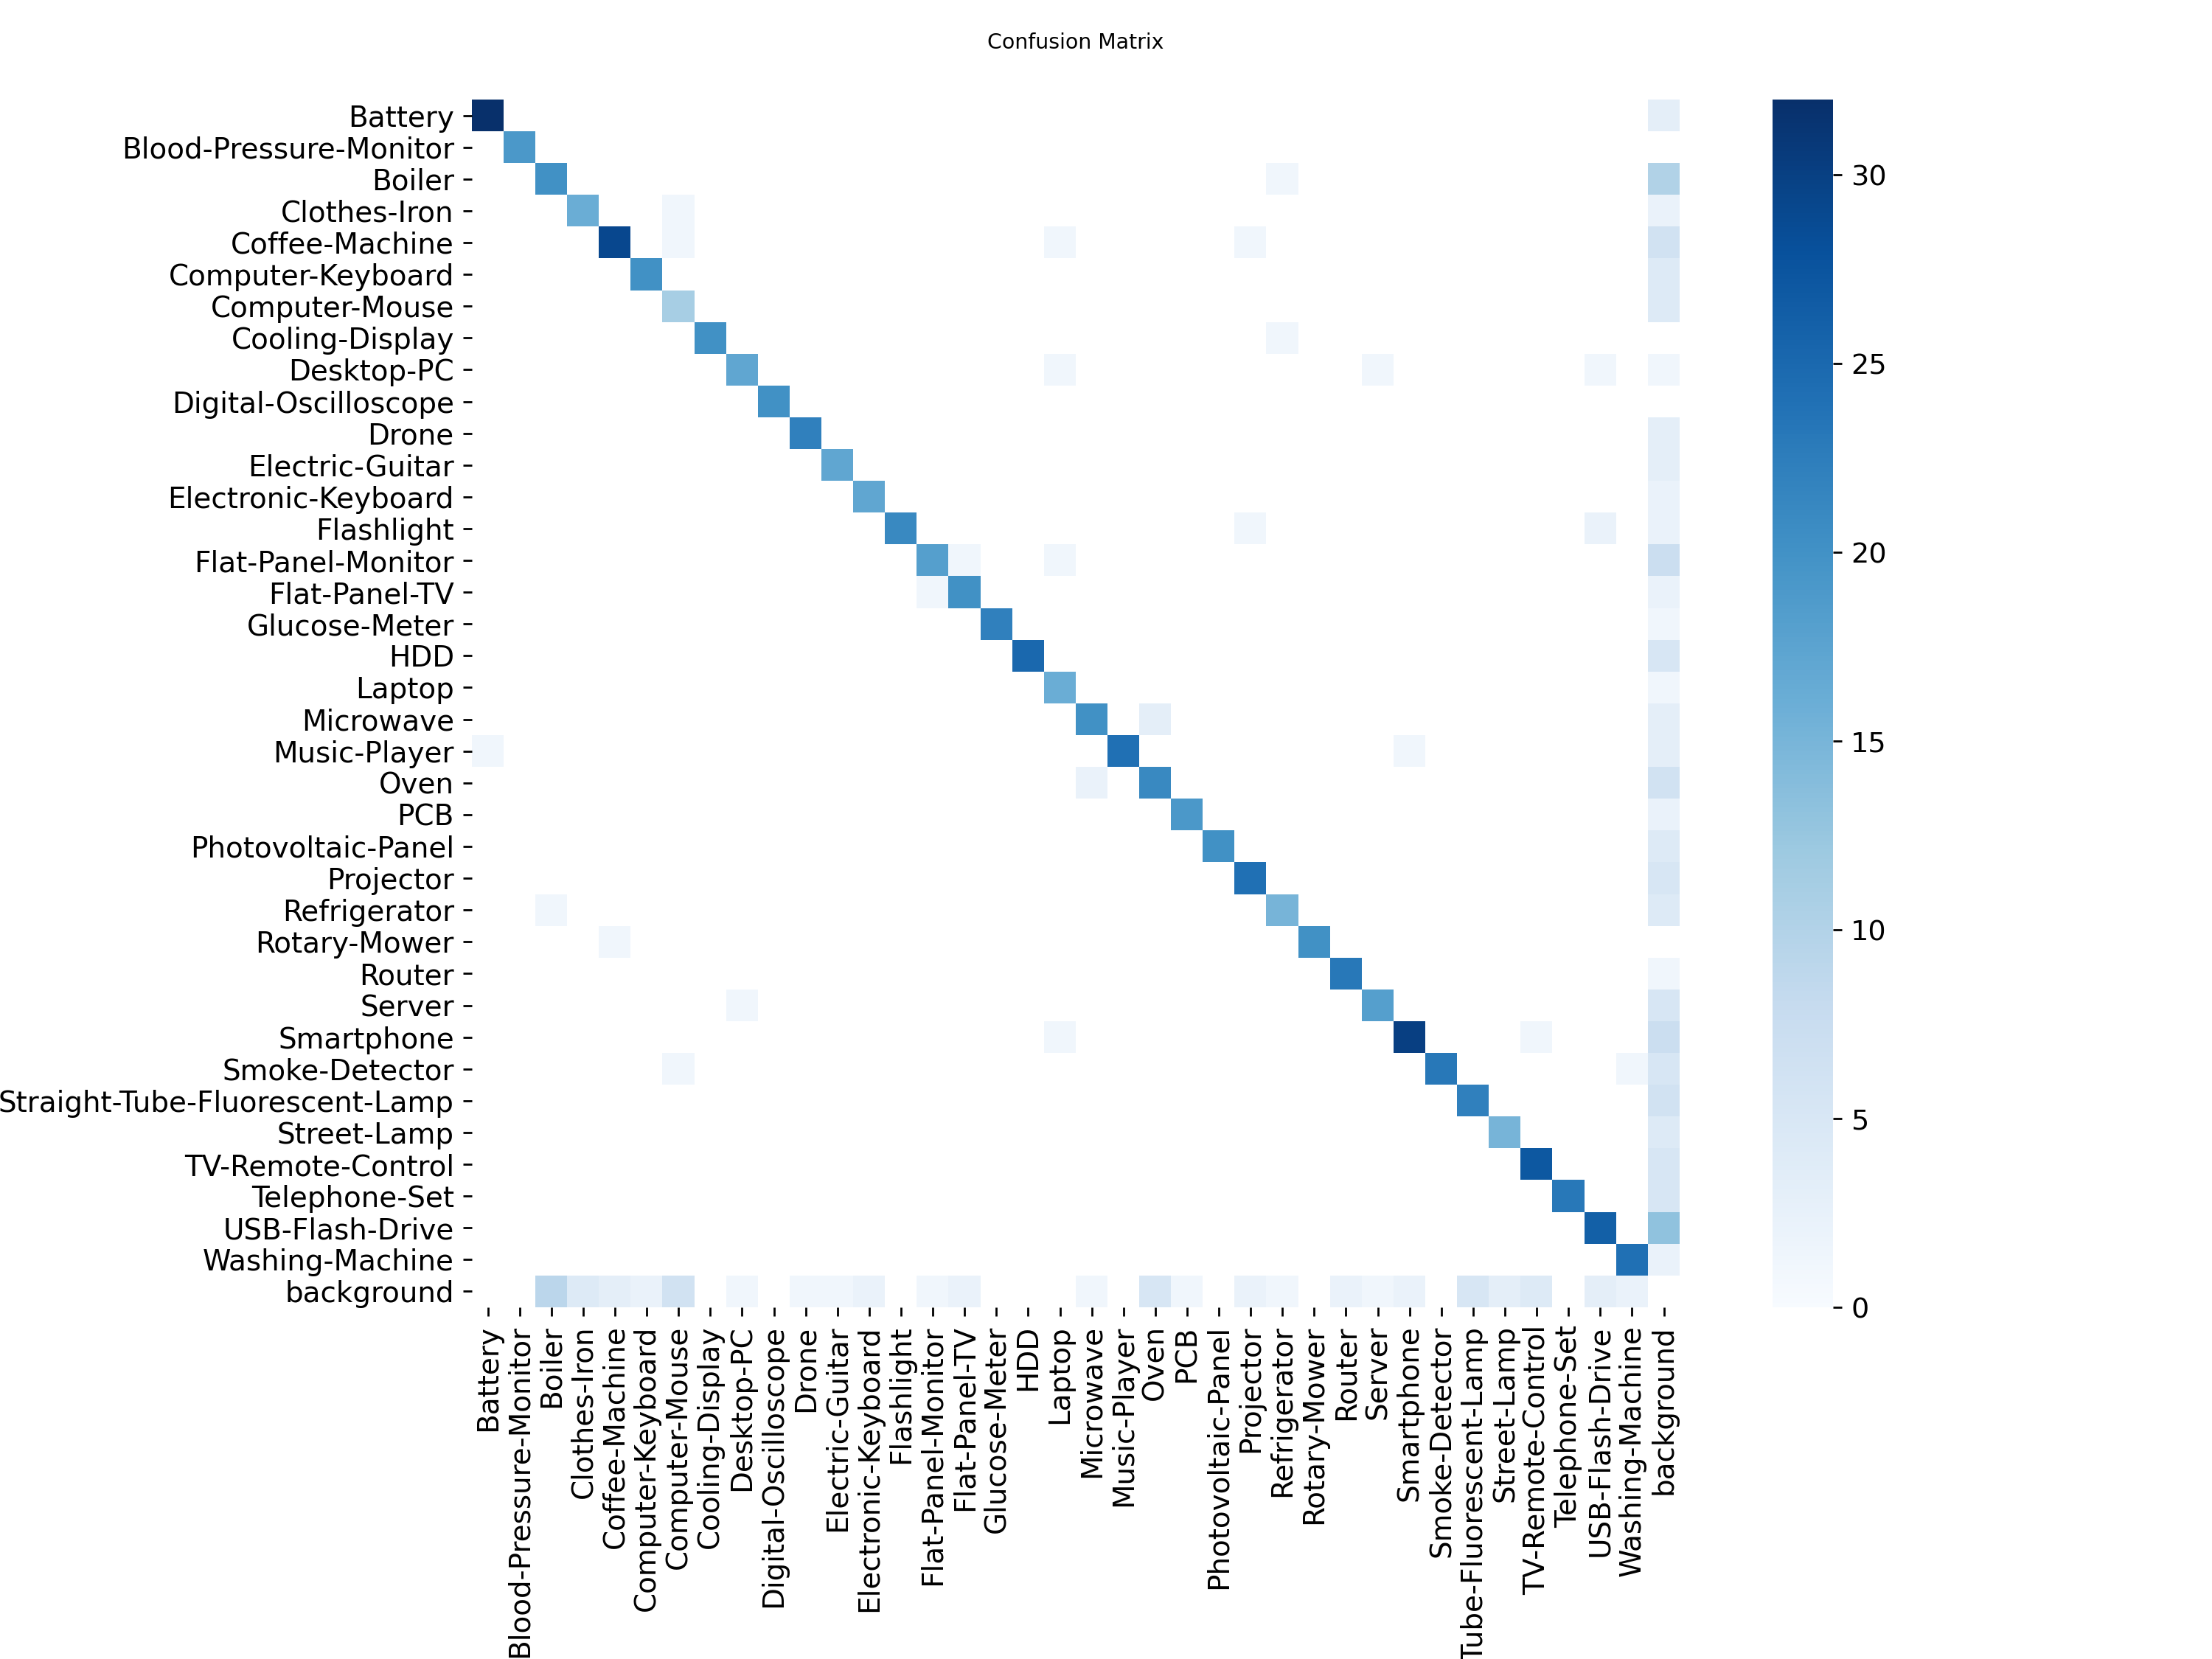

In [35]:
from PIL import Image
from IPython.display import display
from pathlib import Path

EVAL_DIR = Path(
    "/content/drive/MyDrive/CV_Project/yolo26n_evaluation"
)

# Display standard confusion matrix
confusion_matrix_path = EVAL_DIR / "confusion_matrix.png"

print("=" * 75)
print("CONFUSION MATRIX")
print("=" * 75)

print(f"\nFile:")
print(confusion_matrix_path)

print(f"Exists: {confusion_matrix_path.exists()}")

if not confusion_matrix_path.exists():
    raise FileNotFoundError(
        "confusion_matrix.png was not found."
    )

display(Image.open(confusion_matrix_path))

## 29.1 Normalized Confusion Matrix

The normalized confusion matrix represents the classification behavior using normalized values, making it easier to compare recognition performance across classes with different numbers of instances.

NORMALIZED CONFUSION MATRIX

File:
/content/drive/MyDrive/CV_Project/yolo26n_evaluation/confusion_matrix_normalized.png
Exists: True


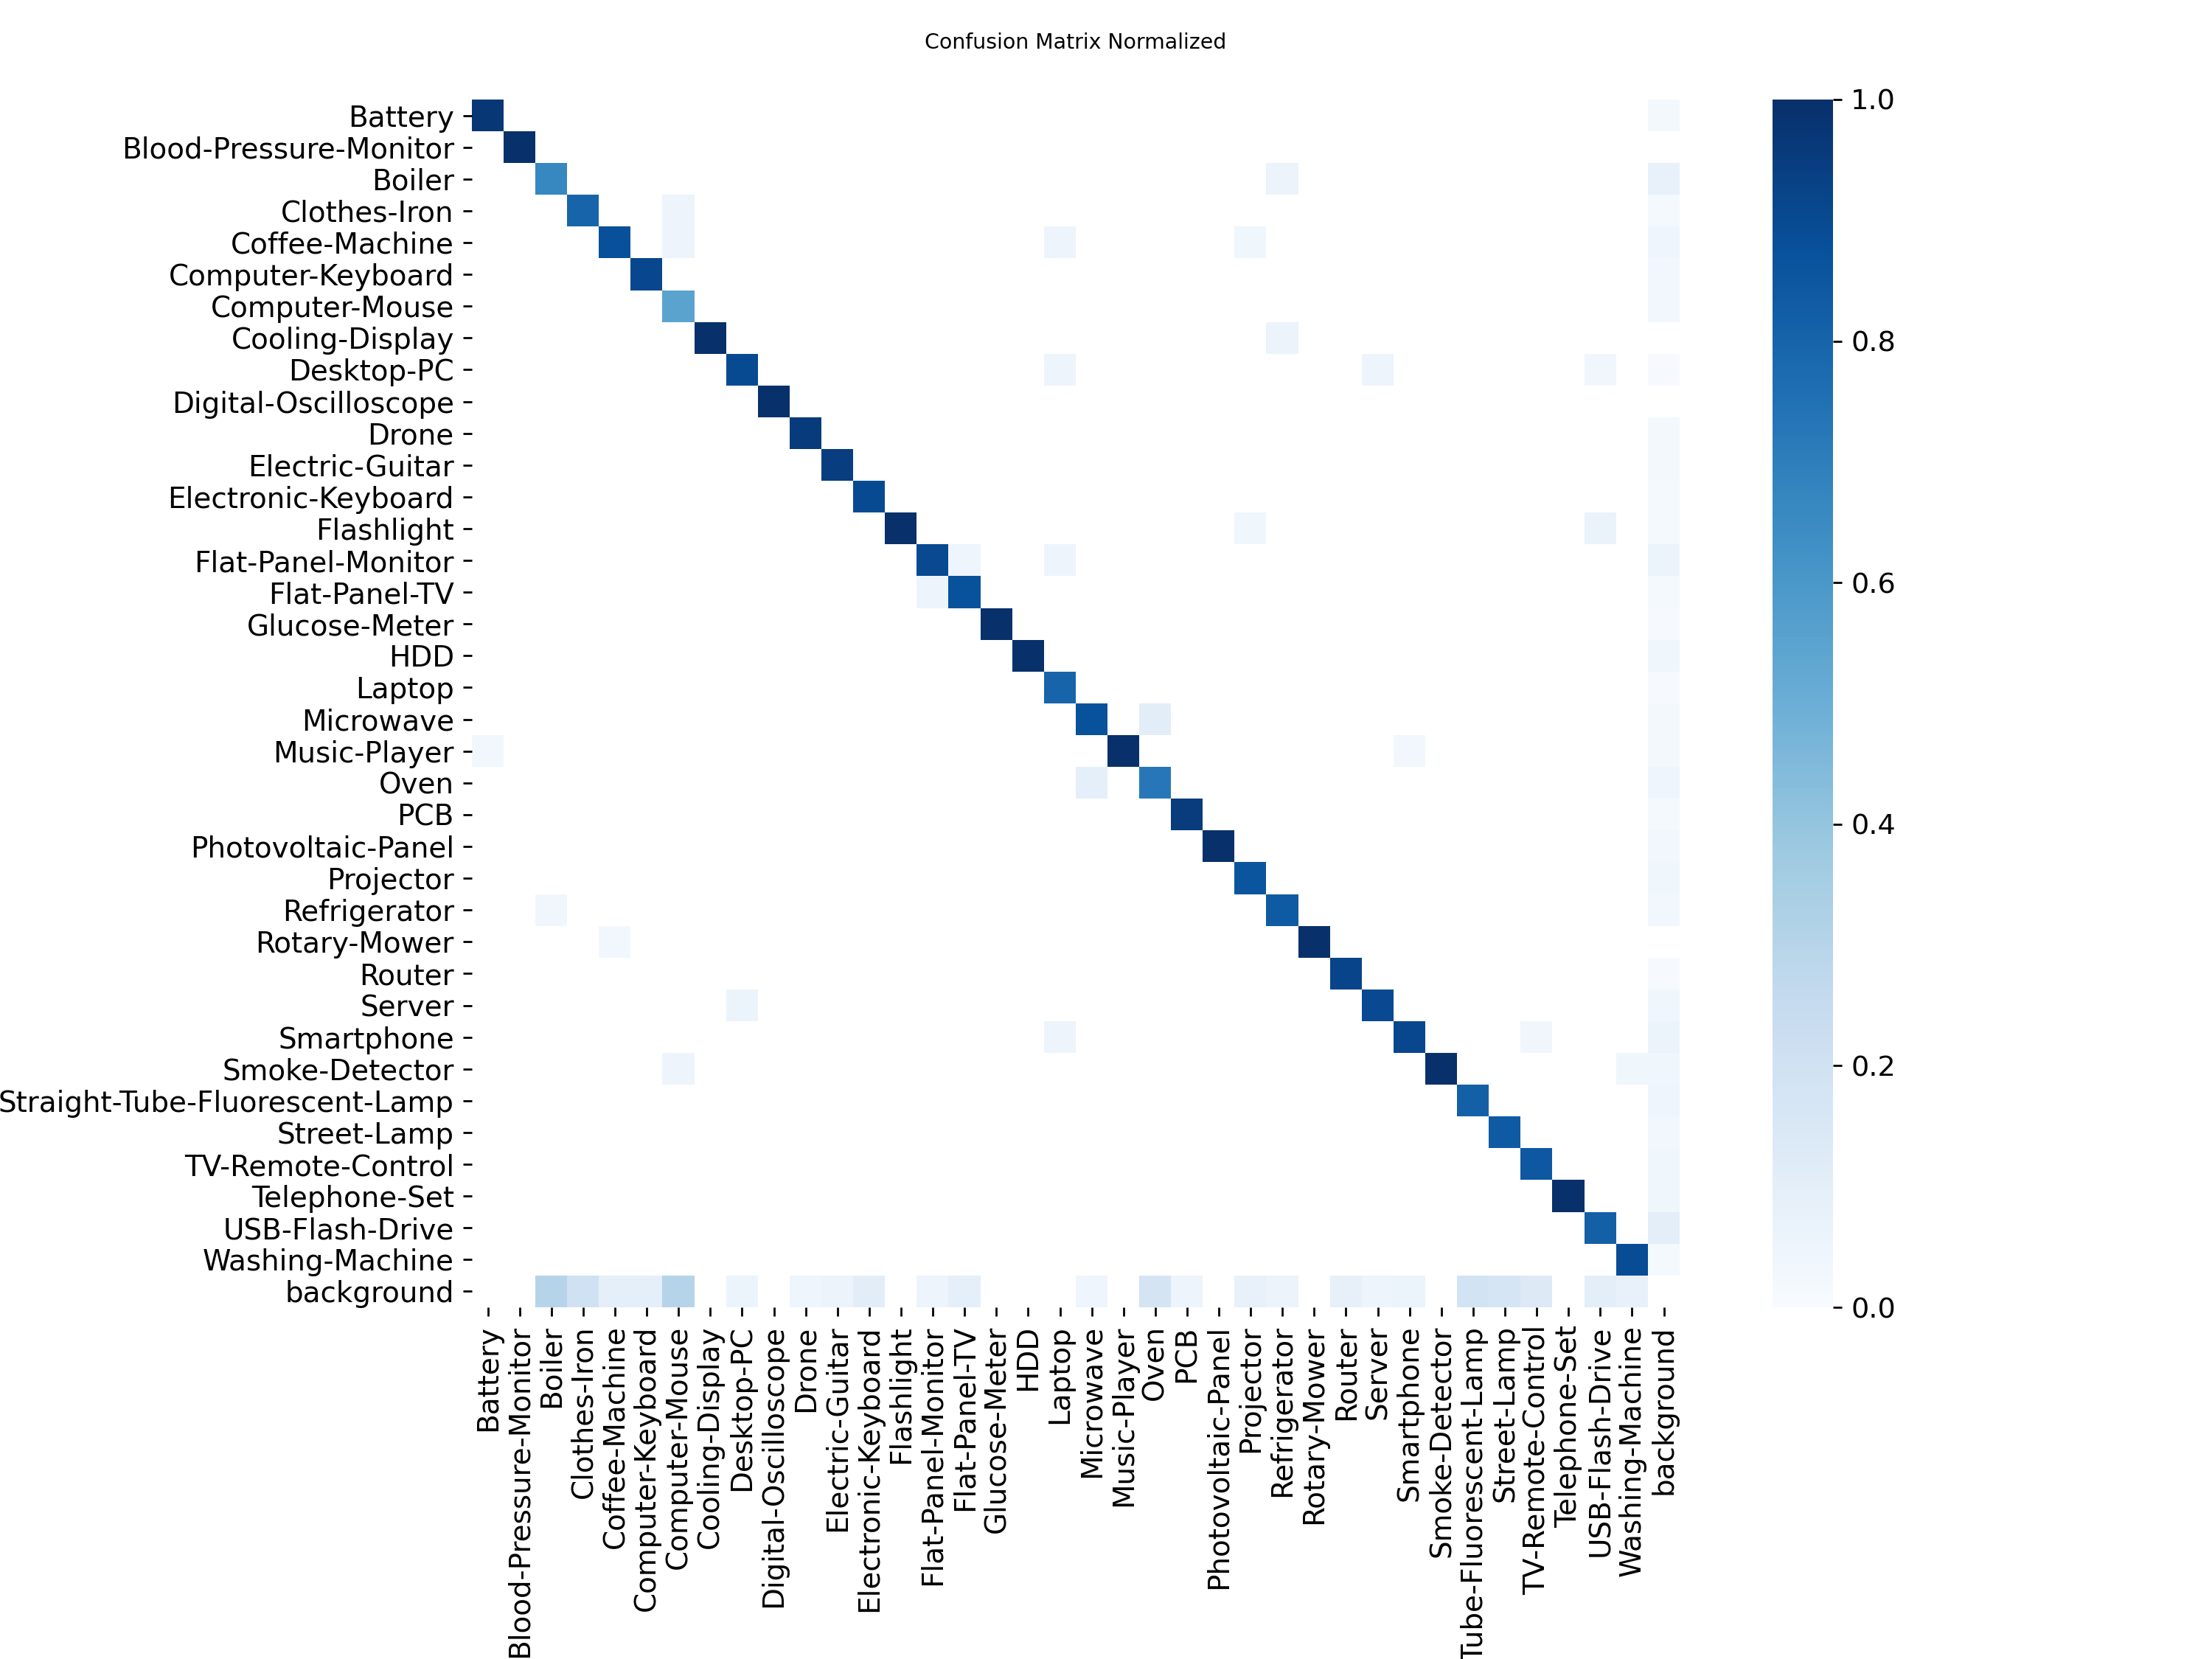

In [36]:
normalized_cm_path = (
    EVAL_DIR / "confusion_matrix_normalized.png"
)

print("=" * 75)
print("NORMALIZED CONFUSION MATRIX")
print("=" * 75)

print(f"\nFile:")
print(normalized_cm_path)

print(f"Exists: {normalized_cm_path.exists()}")

if not normalized_cm_path.exists():
    raise FileNotFoundError(
        "confusion_matrix_normalized.png was not found."
    )

display(Image.open(normalized_cm_path))

## 30. Evaluation Summary

The YOLO26n model was evaluated on an independent test set containing 776 images and 869 annotated object instances.

The overall test performance was:

- Precision: 0.923
- Recall: 0.863
- mAP@50: 0.919
- mAP@50–95: 0.756

The confusion matrix and class-level results show that the model can distinguish the majority of the 37 electronic-waste categories.

The evaluation results provide evidence that the trained YOLO26n model is ready for image-based object detection and classification experiments.

The model will next be tested on individual images before being used in a real-time camera demonstration.

In [37]:
print("=" * 75)
print("PHASE 4 - TRAINING AND EVALUATION COMPLETED")
print("=" * 75)

print("\nModel        : YOLO26n")
print("Classes      : 37")
print("Train images : 4990")
print("Val images   : 1444")
print("Test images  : 776")

print("\nTest Performance")
print("-" * 75)
print("Precision    : 0.923")
print("Recall       : 0.863")
print("mAP@50       : 0.919")
print("mAP@50-95    : 0.756")

print("\n✓ TRAINING COMPLETED")
print("✓ TEST EVALUATION COMPLETED")
print("✓ EVALUATION ARTIFACTS SAVED")
print("✓ MODEL READY FOR IMAGE DETECTION")
print("=" * 75)

PHASE 4 - TRAINING AND EVALUATION COMPLETED

Model        : YOLO26n
Classes      : 37
Train images : 4990
Val images   : 1444
Test images  : 776

Test Performance
---------------------------------------------------------------------------
Precision    : 0.923
Recall       : 0.863
mAP@50       : 0.919
mAP@50-95    : 0.756

✓ TRAINING COMPLETED
✓ TEST EVALUATION COMPLETED
✓ EVALUATION ARTIFACTS SAVED
✓ MODEL READY FOR IMAGE DETECTION
